In [1]:
import pandas as pd
df = pd.read_csv("cleaned_kids_screentime.csv")

df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,activity_type,...,device_type,Duration_Category,High_Education_Use,Exceeded_Flag,weekday_flag,Device_Type,Usage_Day_Type,Usage_Focus,Device_Preference,Health_Impact_Category
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Early Teen,Recreational Usage,...,portable,Moderate (2-4 hrs),False,True,weekday,Other,Below_Mean,Recreational_Dominant,Other_User,"['Poor Sleep', ' Eye Strain']"
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teen,Recreational Usage,...,portable,High (4-6 hrs),False,True,weekend,Portable,Above_Mean,Recreational_Dominant,Portable_User,['Poor Sleep']
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teen,Recreational Usage,...,wall-mounted,Moderate (2-4 hrs),False,True,weekday,Wall_Mounted,Below_Mean,Recreational_Dominant,Wall_Device_User,['Poor Sleep']
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,Late Teen,Recreational Usage,...,portable,Low (0-2 hrs),False,False,weekday,Portable,Below_Mean,Recreational_Dominant,Portable_User,NaN
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Early Teen,Recreational Usage,...,portable,High (4-6 hrs),False,True,weekend,Other,Above_Mean,Recreational_Dominant,Other_User,"['Poor Sleep', ' Anxiety']"


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
 8   Age_Band                           9712 non-null   object 
 9   activity_type                      9712 non-null   object 
 10  health_issue_present               9712 non-null   object 
 11  device_type                        9712 non-null   objec

In [3]:
print(df.dtypes)

Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
Age_Band                              object
activity_type                         object
health_issue_present                  object
device_type                           object
Duration_Category                     object
High_Education_Use                      bool
Exceeded_Flag                           bool
weekday_flag                          object
Device_Type                           object
Usage_Day_Type                        object
Usage_Focus                           object
Device_Preference                     object
Health_Impact_Category                object
dtype: object


In [4]:
import matplotlib.pyplot as plt

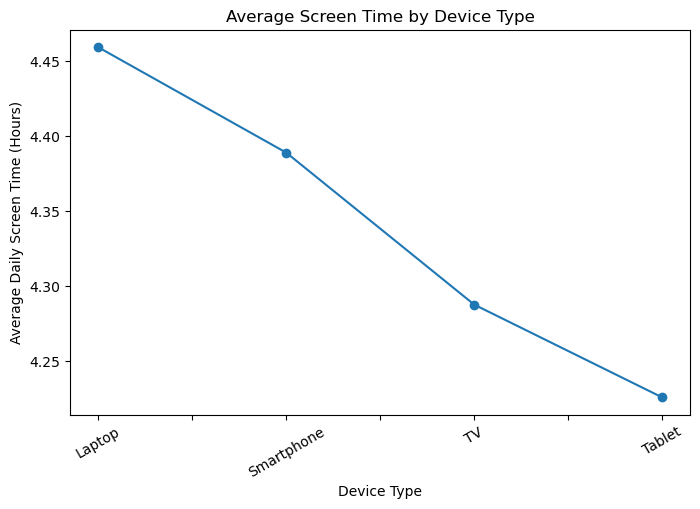

In [5]:
# Line plot showing average screen time for each primary device type
device_usage = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(8,5))
device_usage.plot(marker='o')

plt.title("Average Screen Time by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.xticks(rotation=30)

plt.show()

In [6]:
import seaborn as sns

sns.set(style="whitegrid")

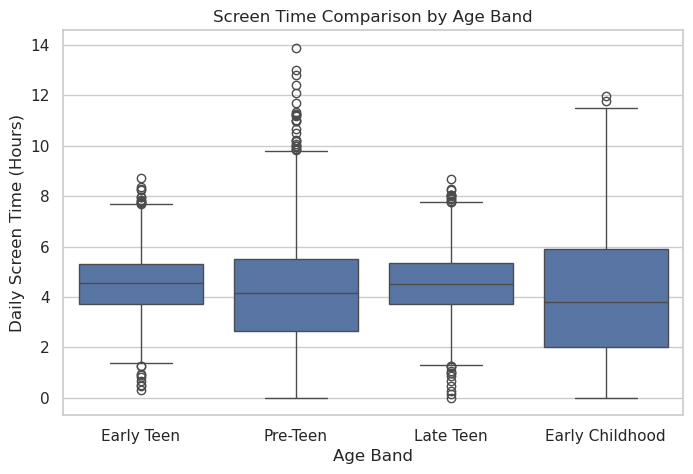

In [7]:
# Boxplot comparing daily screen time across different age bands
plt.figure(figsize=(8,5))

sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time Comparison by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

<Figure size 800x500 with 0 Axes>

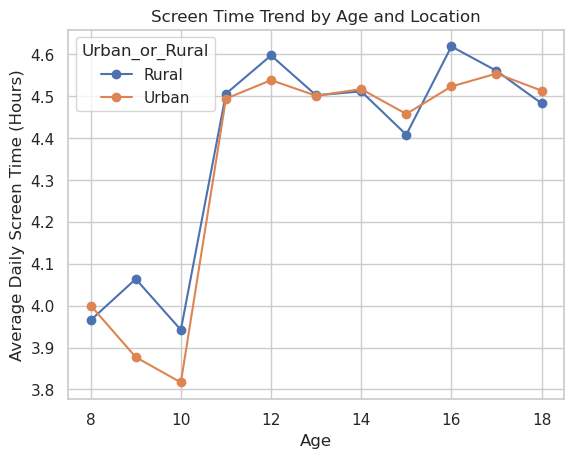

In [8]:
# Line plot showing screen time trend across ages for urban vs rural kids
location_age = df.groupby(["Age","Urban_or_Rural"])["Avg_Daily_Screen_Time_hr"].mean().unstack()

plt.figure(figsize=(8,5))
location_age.plot(marker='o')

plt.title("Screen Time Trend by Age and Location")
plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.show()

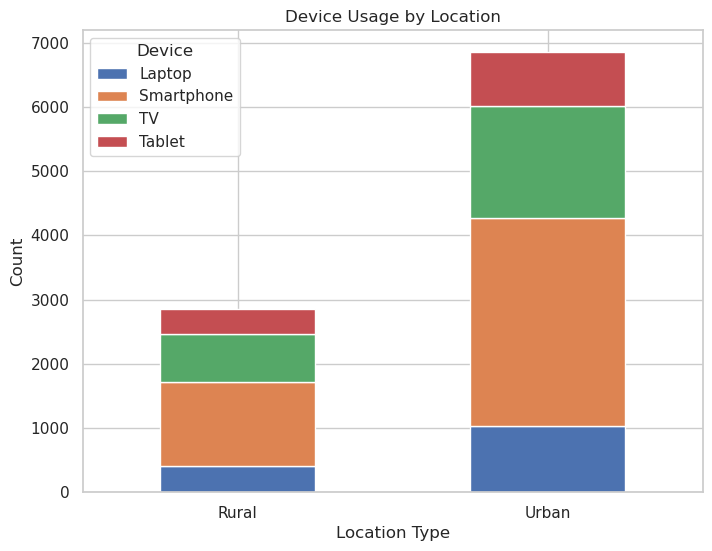

In [9]:
# Stacked bar chart showing device usage differences between urban and rural kids
pd.crosstab(df['Urban_or_Rural'], df['Primary_Device']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Device Usage by Location")
plt.xlabel("Location Type")
plt.ylabel("Count")

plt.legend(title="Device")
plt.xticks(rotation=0)

plt.show()

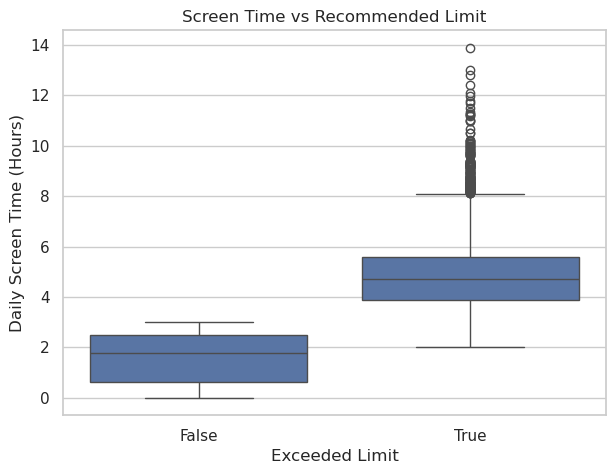

In [10]:
# Boxplot showing screen time distribution for kids who exceeded recommended limit
plt.figure(figsize=(7,5))
sns.boxplot(x='Exceeded_Recommended_Limit', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time vs Recommended Limit")
plt.xlabel("Exceeded Limit")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

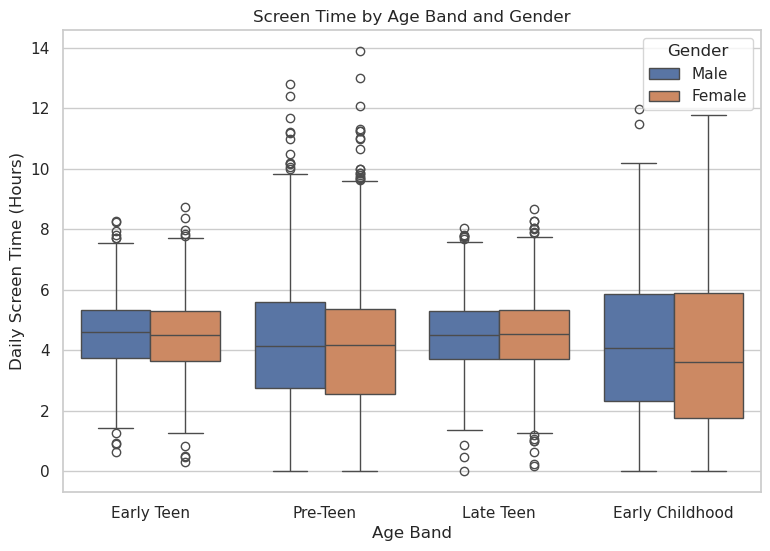

In [11]:
# Boxplot comparing screen time across age bands separated by gender
plt.figure(figsize=(9,6))

sns.boxplot(
    x='Age_Band',
    y='Avg_Daily_Screen_Time_hr',
    hue='Gender',
    data=df
)

plt.title("Screen Time by Age Band and Gender")
plt.xlabel("Age Band")
plt.ylabel("Daily Screen Time (Hours)")

plt.legend(title="Gender")

plt.show()

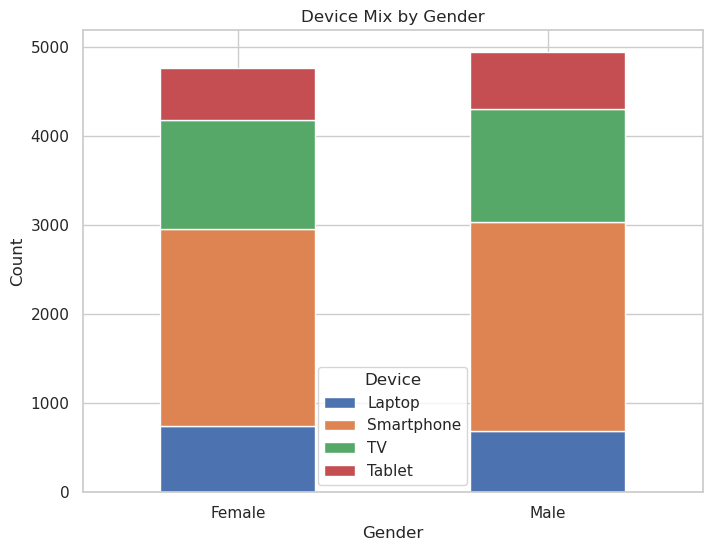

 Insight:

Smartphones dominate across both genders.
Minor variation exists in secondary devices like tablets or laptops.
Indicates device accessibility is similar across genders.
Gender is not a strong differentiator for device choice.
Mobile-first behavior is clearly visible.
Peak usage likely driven by universally accessible devices. 


In [12]:
# Stacked bar chart showing device usage composition by gender
pd.crosstab(df['Gender'], df['Primary_Device']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Device Mix by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Device")

plt.show()

print(""" Insight:

Smartphones dominate across both genders.
Minor variation exists in secondary devices like tablets or laptops.
Indicates device accessibility is similar across genders.
Gender is not a strong differentiator for device choice.
Mobile-first behavior is clearly visible.
Peak usage likely driven by universally accessible devices. """)

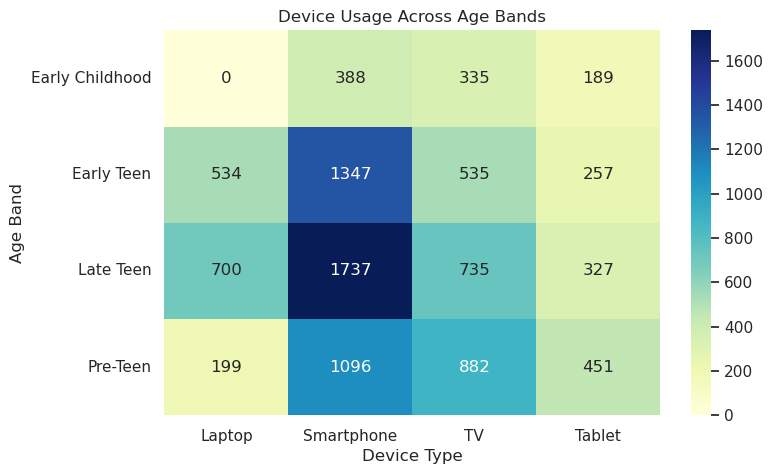

 Insight:

Older age groups show higher overall device usage.
Smartphone usage increases with age.
Younger kids may use shared or limited devices.
Device diversity increases in higher age bands.
Indicates independence and access grow with age.
Older teens form a peak usage cohort. 


In [13]:
# Heatmap showing device preference across age bands
device_age = pd.crosstab(df['Age_Band'], df['Primary_Device'])

plt.figure(figsize=(8,5))
sns.heatmap(device_age, annot=True, cmap="YlGnBu", fmt='d')

plt.title("Device Usage Across Age Bands")
plt.xlabel("Device Type")
plt.ylabel("Age Band")

plt.show()

print(""" Insight:

Older age groups show higher overall device usage.
Smartphone usage increases with age.
Younger kids may use shared or limited devices.
Device diversity increases in higher age bands.
Indicates independence and access grow with age.
Older teens form a peak usage cohort. """)

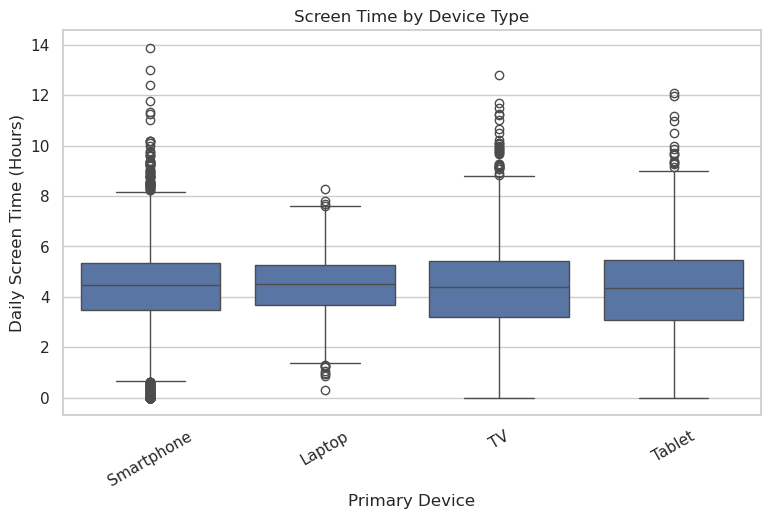

In [14]:
# Boxplot comparing screen time distribution across device types
plt.figure(figsize=(9,5))

sns.boxplot(
    x='Primary_Device',
    y='Avg_Daily_Screen_Time_hr',
    data=df
)

plt.title("Screen Time by Device Type")
plt.xlabel("Primary Device")
plt.ylabel("Daily Screen Time (Hours)")

plt.xticks(rotation=30)

plt.show()

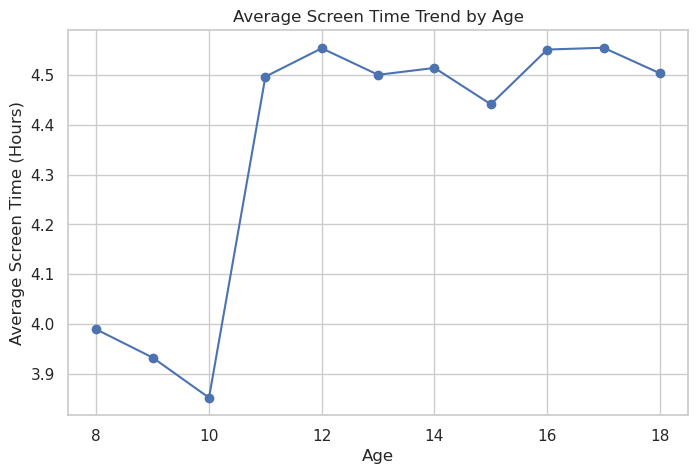

In [15]:
# Line plot showing how screen time changes with age
age_trend = df.groupby("Age")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(8,5))
age_trend.plot(marker='o')

plt.title("Average Screen Time Trend by Age")
plt.xlabel("Age")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

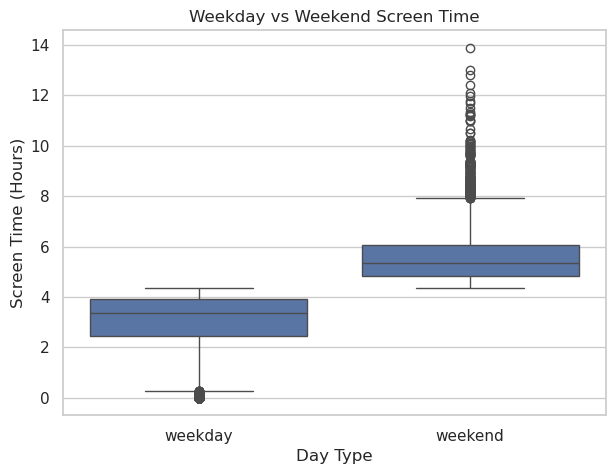

 Insight:

Weekend screen time is clearly higher than weekday.
Median increases significantly on weekends.
Greater variability indicates flexible usage patterns.
Outliers show heavy binge usage during weekends.
Weekdays are more structured and controlled.
Weekends form the strongest peak usage period. 


In [16]:
# Boxplot comparing weekday and weekend screen time
plt.figure(figsize=(7,5))

sns.boxplot(
    x='weekday_flag',
    y='Avg_Daily_Screen_Time_hr',
    data=df
)

plt.title("Weekday vs Weekend Screen Time")
plt.xlabel("Day Type")
plt.ylabel("Screen Time (Hours)")

plt.show()

print(""" Insight:

Weekend screen time is clearly higher than weekday.
Median increases significantly on weekends.
Greater variability indicates flexible usage patterns.
Outliers show heavy binge usage during weekends.
Weekdays are more structured and controlled.
Weekends form the strongest peak usage period. """)

<Figure size 800x500 with 0 Axes>

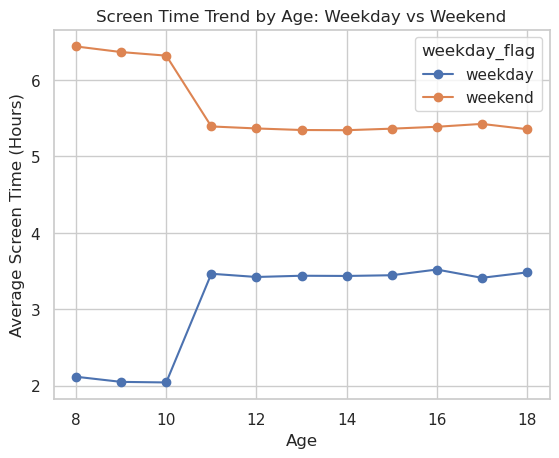

In [17]:
# Line plot comparing screen time trend across ages for weekday and weekend
age_trend = df.groupby(['Age','weekday_flag'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(8,5))
age_trend.plot(marker='o')

plt.title("Screen Time Trend by Age: Weekday vs Weekend")
plt.xlabel("Age")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

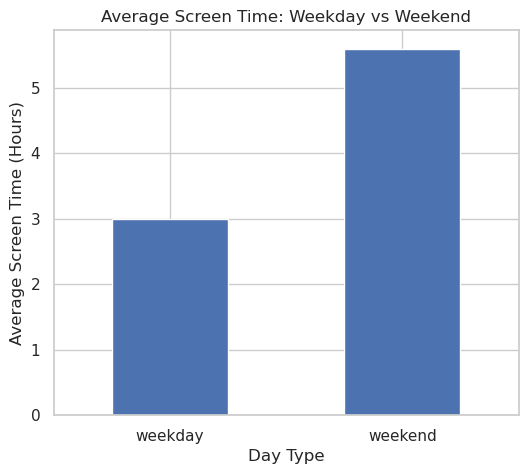

In [18]:
# Bar chart showing average screen time for weekday and weekend
weekday_avg = df.groupby('weekday_flag')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
weekday_avg.plot(kind='bar')

plt.title("Average Screen Time: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")

plt.xticks(rotation=0)

plt.show()

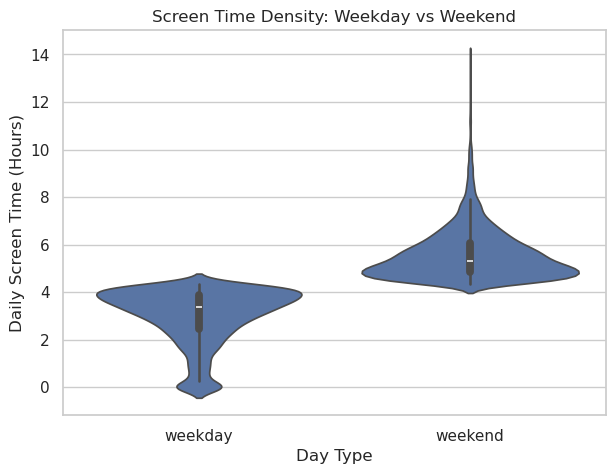

In [19]:
# Violin plot showing density distribution of screen time for weekday and weekend
plt.figure(figsize=(7,5))

sns.violinplot(
    x='weekday_flag',
    y='Avg_Daily_Screen_Time_hr',
    data=df
)

plt.title("Screen Time Density: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

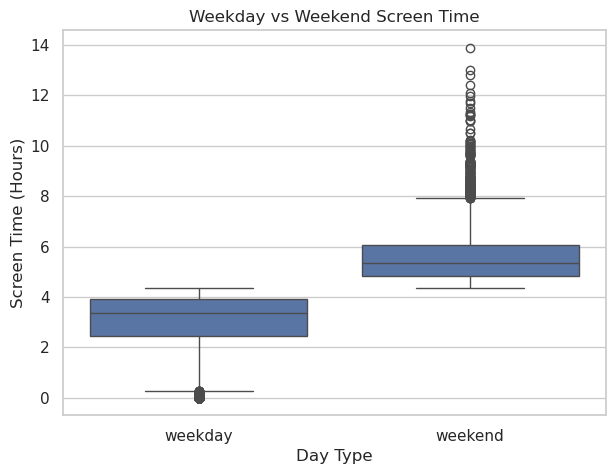

 Insight:

Weekend screen time is clearly higher than weekday.
Median increases significantly on weekends.
Greater variability indicates flexible usage patterns.
Outliers show heavy binge usage during weekends.
Weekdays are more structured and controlled.
Weekends form the strongest peak usage period. 


In [20]:
# Boxplot comparing weekday and weekend screen time
plt.figure(figsize=(7,5))

sns.boxplot(
    x='weekday_flag',
    y='Avg_Daily_Screen_Time_hr',
    data=df
)

plt.title("Weekday vs Weekend Screen Time")
plt.xlabel("Day Type")
plt.ylabel("Screen Time (Hours)")

plt.show()

print(""" Insight:

Weekend screen time is clearly higher than weekday.
Median increases significantly on weekends.
Greater variability indicates flexible usage patterns.
Outliers show heavy binge usage during weekends.
Weekdays are more structured and controlled.
Weekends form the strongest peak usage period. """)

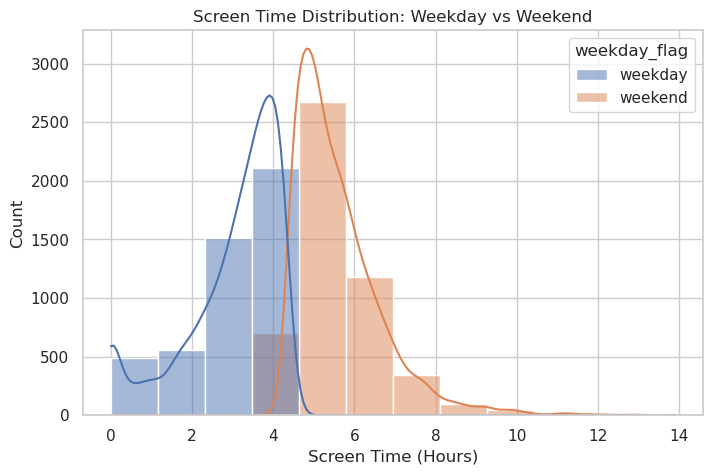

 Insight:

Weekend distribution shifts toward higher values.
Weekday usage is concentrated in moderate ranges.
More users exceed high screen time thresholds on weekends.
Indicates relaxed schedules and more free time.
Density curve highlights behavioral difference clearly.
Confirms weekend-driven screen spikes. 


In [21]:
# Histogram comparing distribution of screen time
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Avg_Daily_Screen_Time_hr',
    hue='weekday_flag',
    bins=12,
    kde=True
)

plt.title("Screen Time Distribution: Weekday vs Weekend")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Count")

plt.show()

print(""" Insight:

Weekend distribution shifts toward higher values.
Weekday usage is concentrated in moderate ranges.
More users exceed high screen time thresholds on weekends.
Indicates relaxed schedules and more free time.
Density curve highlights behavioral difference clearly.
Confirms weekend-driven screen spikes. """)

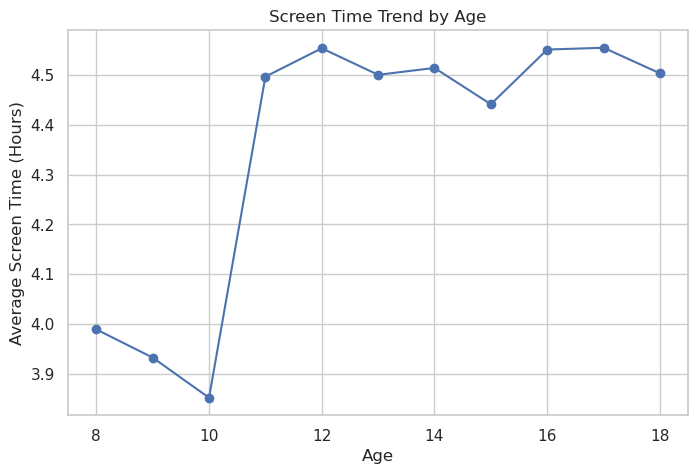

 Insight:

Screen time increases steadily with age.
Older users show higher digital engagement.
Teenagers form the highest usage group.
Reflects increased autonomy and device ownership.
Trend is consistent and predictable.
Older age groups are peak usage cohort. 


In [22]:
# Line plot showing trend of screen time across age
age_trend = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(8,5))
age_trend.plot(marker='o')

plt.title("Screen Time Trend by Age")
plt.xlabel("Age")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

print(""" Insight:

Screen time increases steadily with age.
Older users show higher digital engagement.
Teenagers form the highest usage group.
Reflects increased autonomy and device ownership.
Trend is consistent and predictable.
Older age groups are peak usage cohort. """)

In [23]:
print("""Peak usage cohorts identified:

Weekend users show significantly higher screen time compared to weekdays.
Older age groups tend to use multiple devices and spend more time on screens.
Urban users demonstrate higher engagement, especially in recreational activities.
Mobile device users dominate across all demographics, forming the largest usage group.
Recreational activity users exhibit the highest screen time, making them the primary high-risk cohort. """)

Peak usage cohorts identified:

Weekend users show significantly higher screen time compared to weekdays.
Older age groups tend to use multiple devices and spend more time on screens.
Urban users demonstrate higher engagement, especially in recreational activities.
Mobile device users dominate across all demographics, forming the largest usage group.
Recreational activity users exhibit the highest screen time, making them the primary high-risk cohort. 


Histogram by Age Group:


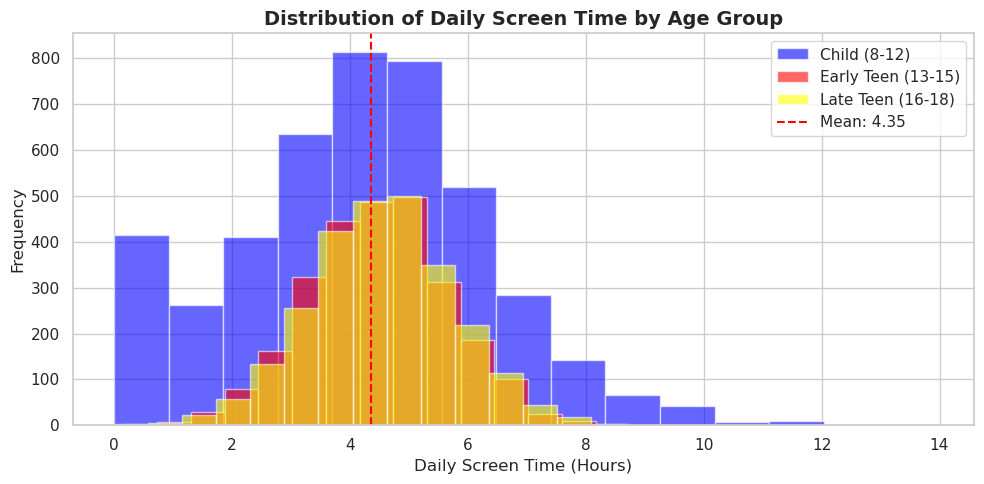

- Children (8-12) show a bimodal distribution with peaks at 1-2 hrs and 4-5 hrs
- Late Teens (16-18) are concentrated around the mean (4.35 hrs), bell-shaped
- Early Teens (13-15) have the smallest group size in this dataset
- Most kids cluster between 3-6 hours of daily screen time


In [24]:
print("Histogram by Age Group:")
import pandas as pd
import matplotlib.pyplot as plt

bins = [7, 12, 15, 18]
labels = ['Child (8-12)', 'Early Teen (13-15)', 'Late Teen (16-18)']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
mean_time = df['Avg_Daily_Screen_Time_hr'].mean()

colors = {'Child (8-12)': 'blue', 'Early Teen (13-15)': 'red', 'Late Teen (16-18)': 'yellow'}
plt.figure(figsize=(10, 5))
for group, color in colors.items():
    subset = df[df['Age_Group'] == group]['Avg_Daily_Screen_Time_hr'].dropna()
    plt.hist(subset, bins=15, alpha=0.6, label=group, color=color, edgecolor='white')
plt.axvline(mean_time, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_time:.2f}')
plt.title("Distribution of Daily Screen Time by Age Group", fontsize=14, fontweight='bold')
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()
print("""- Children (8-12) show a bimodal distribution with peaks at 1-2 hrs and 4-5 hrs
- Late Teens (16-18) are concentrated around the mean (4.35 hrs), bell-shaped
- Early Teens (13-15) have the smallest group size in this dataset
- Most kids cluster between 3-6 hours of daily screen time""")

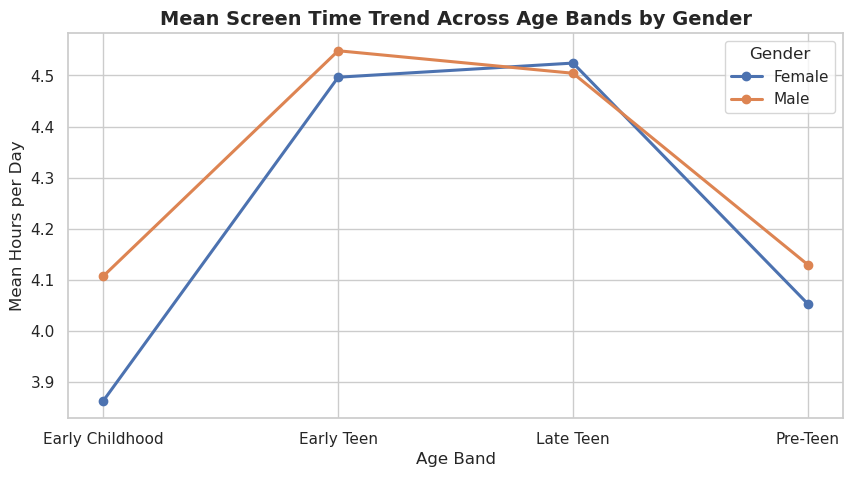

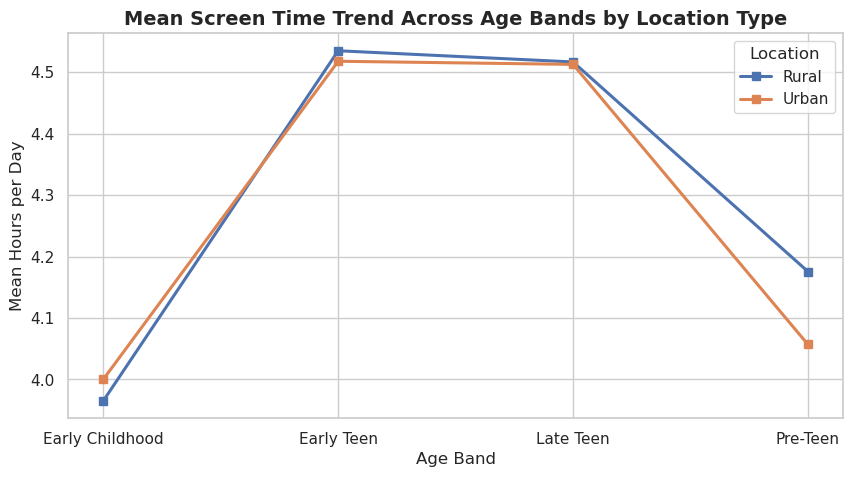

In [25]:
# Line Plot – Trend: Mean Screen Time across Age Bands (by Gender)
pivot = (df.groupby(["Age_Band", "Gender"], observed=True)["Avg_Daily_Screen_Time_hr"]
           .mean().reset_index())
fig, ax = plt.subplots(figsize=(10, 5))
for gender_val, grp in pivot.groupby("Gender"):
    ax.plot(grp["Age_Band"].astype(str), grp["Avg_Daily_Screen_Time_hr"],
            marker="o", linewidth=2.2, label=gender_val)
ax.set_title("Mean Screen Time Trend Across Age Bands by Gender",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Age Band")
ax.set_ylabel("Mean Hours per Day")
ax.legend(title="Gender")
# Line Plot – Mean Screen Time by Age Band (Urban vs Rural)
pivot2 = (df.groupby(["Age_Band", "Urban_or_Rural"], observed=True)["Avg_Daily_Screen_Time_hr"]
            .mean().reset_index())
fig, ax = plt.subplots(figsize=(10, 5))
for loc_val, grp in pivot2.groupby("Urban_or_Rural"):
    ax.plot(grp["Age_Band"].astype(str), grp["Avg_Daily_Screen_Time_hr"],
            marker="s", linewidth=2.2, label=loc_val)
ax.set_title("Mean Screen Time Trend Across Age Bands by Location Type",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Age Band")
ax.set_ylabel("Mean Hours per Day")
ax.legend(title="Location")

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Theme + styling
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 130, "savefig.bbox": "tight"})

# Dummy dataset (replace with your CSV)
np.random.seed(42)
n = 800
df = pd.DataFrame({
    "Age": np.random.randint(8, 25, n),
    "Gender": np.random.choice(["Male","Female","Non-binary"], n, p=[0.47,0.47,0.06]),
    "Avg_Daily_Screen_Time_hr": np.clip(np.random.normal(6.5, 2.5, n), 0.5, 16),
    "Primary_Device": np.random.choice(["Smartphone","Laptop","Tablet","Desktop","TV"], n, p=[0.40,0.25,0.15,0.10,0.10]),
    "Exceeded_Recommended_Limit": np.random.choice(["Yes","No"], n, p=[0.45,0.55]),
    "Educational_to_Recreational_Ratio": np.clip(np.random.beta(2, 5, n), 0, 1),
    "Health_Impacts": np.random.choice(["None","Mild","Moderate","Severe"], n, p=[0.30,0.35,0.25,0.10]),
    "Urban_or_Rural": np.random.choice(["Urban","Rural"], n, p=[0.65,0.35]),
})

# Age Bands
df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[4, 8, 11, 14, 18],
    labels=["Early Childhood", "Pre-Teen", "Early Teen", "Late Teen"]
)

# Derived Features
df["Device_Mobility"] = df["Primary_Device"].apply(
    lambda d: "Portable" if d in ["Smartphone","Tablet","Laptop"] else "Wall-Mounted")

overall_mean = df["Avg_Daily_Screen_Time_hr"].mean()

df["Usage_Day_Type"] = df["Avg_Daily_Screen_Time_hr"].apply(
    lambda x: "High_Usage_Day" if x > overall_mean else "Normal_Usage_Day")

df["Usage_Category"] = df["Educational_to_Recreational_Ratio"].apply(
    lambda r: "Education-Dominant" if r >= 0.5 else "Recreation-Dominant")

df["Device_Preference"] = df["Device_Mobility"].map({
    "Portable": "Portable-Dominant",
    "Wall-Mounted": "Wall-Mounted-Dominant"
})

df["Health_Severity_Score"] = df["Health_Impacts"].map(
    {"None": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
)

# Orders
AGE_ORDER = ["Child (8-12)", "Early Teen (13-15)", "Late Teen (16-18)", "Young Adult (19-24)"]
HEALTH_ORDER = ["None", "Mild", "Moderate", "Severe"]

# Age palette (cool gradient)
AGE_COLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# Health palette (severity gradient)
HEALTH_COLORS = ["#2ECC71", "#F1C40F", "#E67E22", "#E74C3C"]

# Device palette
DEVICE_COLORS = ["#3498DB", "#9B59B6", "#1ABC9C", "#F39C12", "#E74C3C"]

# Binary palette
BINARY_COLORS = ["#2ECC71", "#E74C3C"]

print("Setup complete — shape:", df.shape)
df["Age_Band"].value_counts().reindex(AGE_ORDER)

Setup complete — shape: (800, 14)


Age_Band
Child (8-12)          NaN
Early Teen (13-15)    NaN
Late Teen (16-18)     NaN
Young Adult (19-24)   NaN
Name: count, dtype: float64

/tmp/ipykernel_228/4199110184.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Age_Band', 'Primary_Device'])['Avg_Daily_Screen_Time_hr']


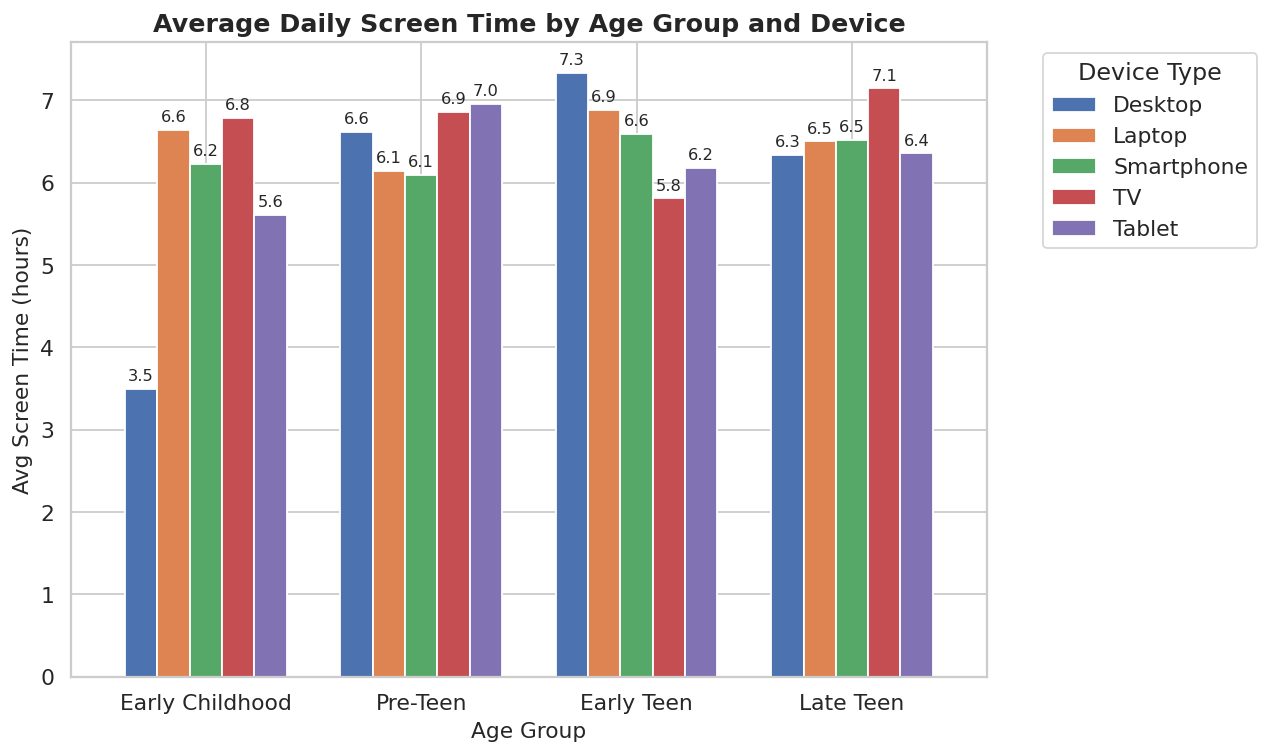

In [28]:
sns.set_theme(style="whitegrid", font_scale=1.1)
cohort_screen = (
    df.groupby(['Age_Band', 'Primary_Device'])['Avg_Daily_Screen_Time_hr']
    .mean()
    .unstack()
)

ax = cohort_screen.plot(
    kind='bar',
    figsize=(10,6),
    width=0.75
)

plt.title('Average Daily Screen Time by Age Group and Device', fontsize=14, weight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Avg Screen Time (hours)', fontsize=12)

plt.xticks(rotation=0)

plt.legend(title='Device Type', bbox_to_anchor=(1.05,1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()

plt.show()

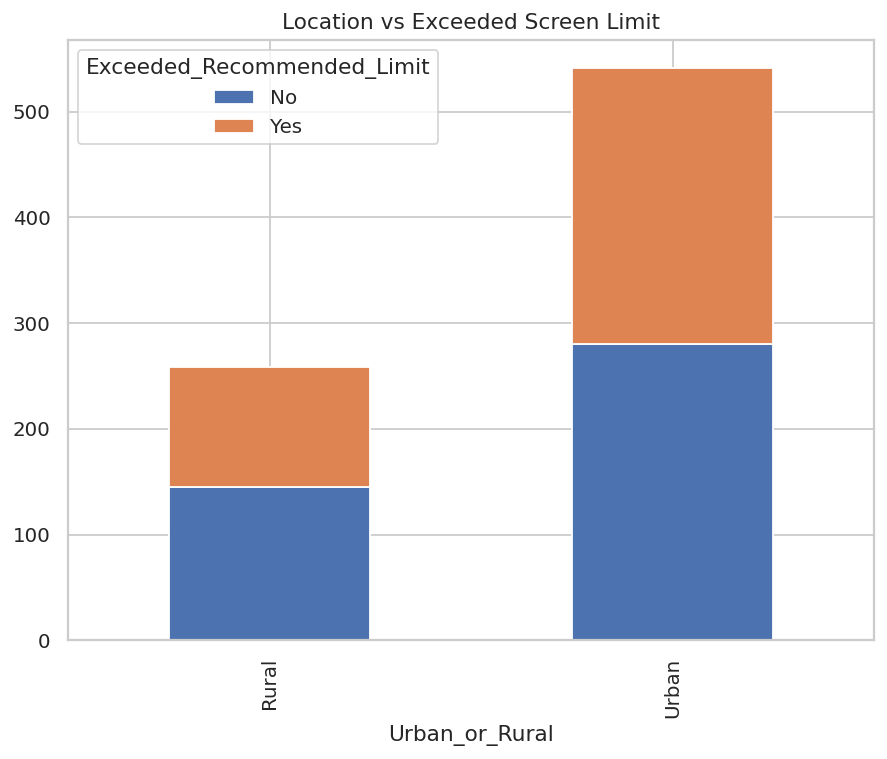

In [30]:
#Location × Exceeded Screen Limit
pd.crosstab(df['Urban_or_Rural'], df['Exceeded_Recommended_Limit']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Location vs Exceeded Screen Limit")
plt.show()

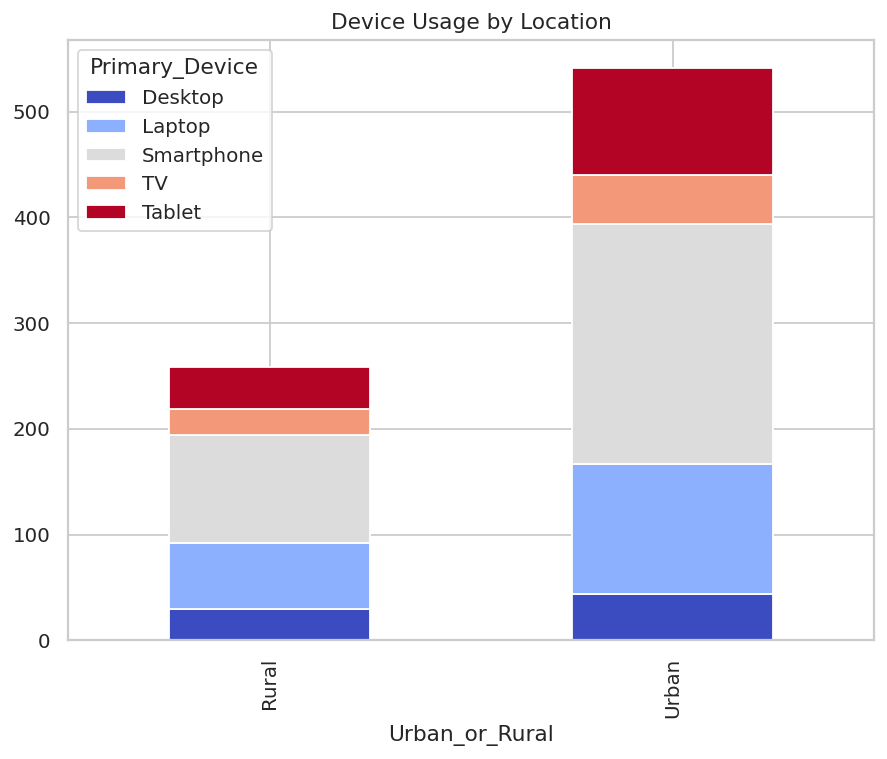

In [31]:
pd.crosstab(df['Urban_or_Rural'], df['Primary_Device']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    colormap='coolwarm'
)

plt.title("Device Usage by Location")
plt.show()

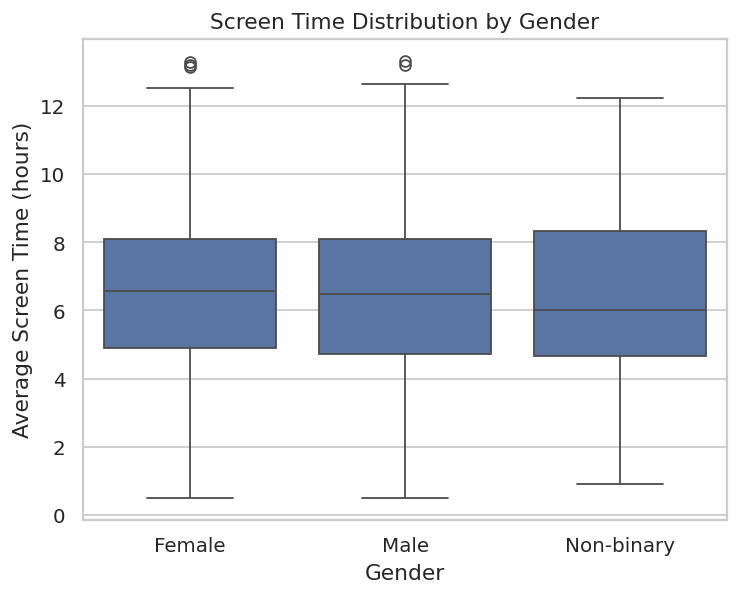

 Observation:

The boxplot indicates differences in screen time distribution between boys and girls, highlighting variations in digital engagement. Some boys exhibit higher maximum screen time compared to girls. Overall screen time between genders may be similar, boys are more likely to engage in extended screen sessions. Such differences may be influenced by activity preferences such as gaming or video streaming. 


In [36]:
#Gender x Screen Time
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (hours)")
plt.show()

print(""" Observation:

The boxplot indicates differences in screen time distribution between boys and girls, highlighting variations in digital engagement. Some boys exhibit higher maximum screen time compared to girls. Overall screen time between genders may be similar, boys are more likely to engage in extended screen sessions. Such differences may be influenced by activity preferences such as gaming or video streaming. """)

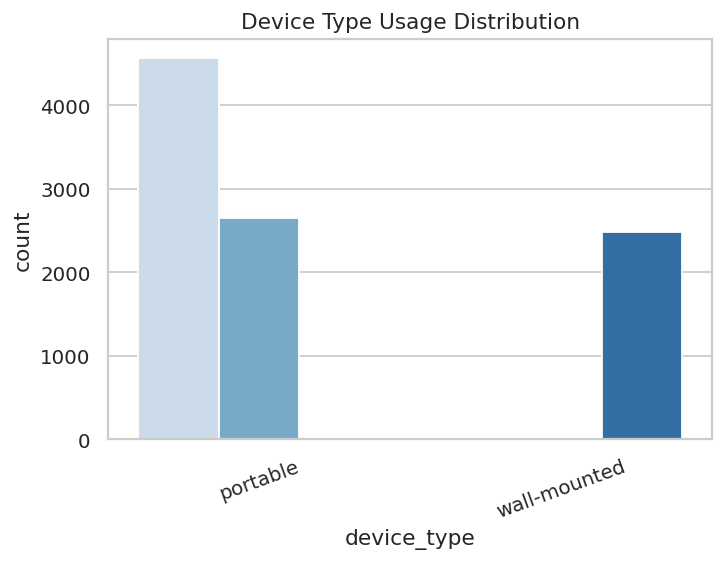

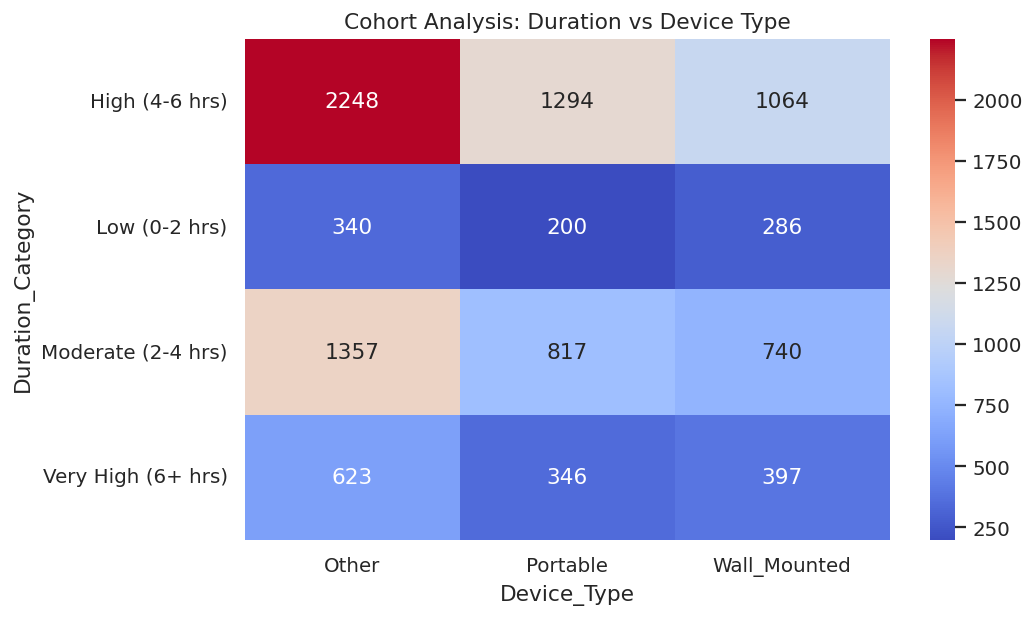

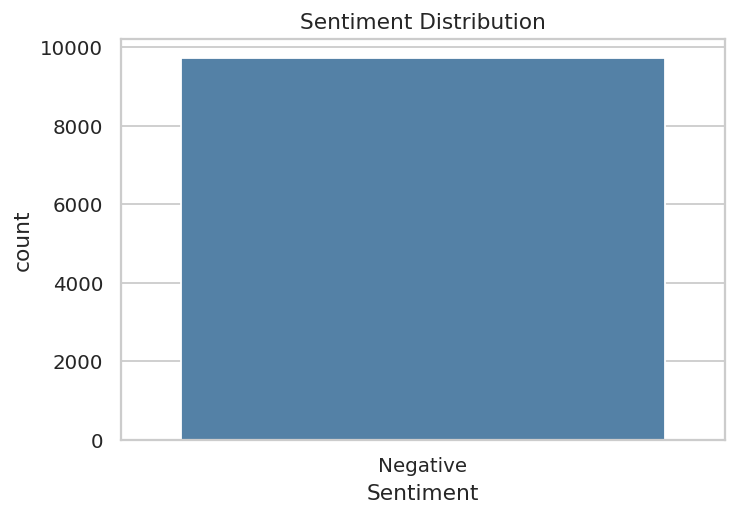

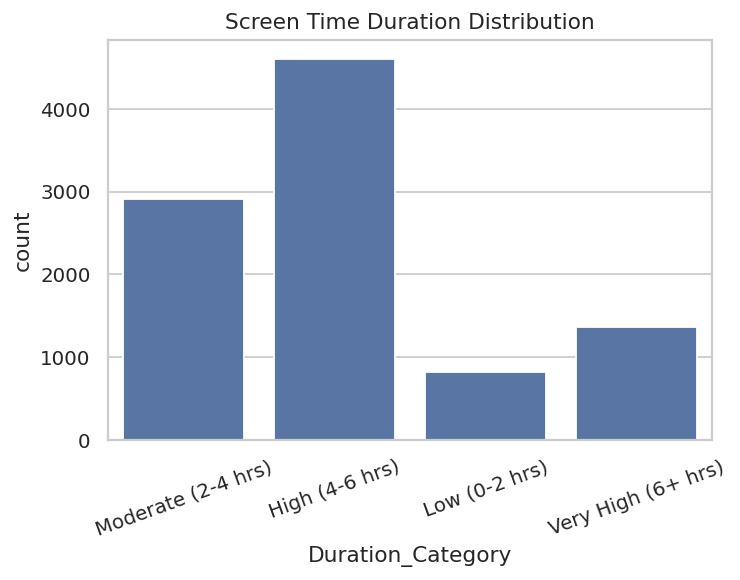

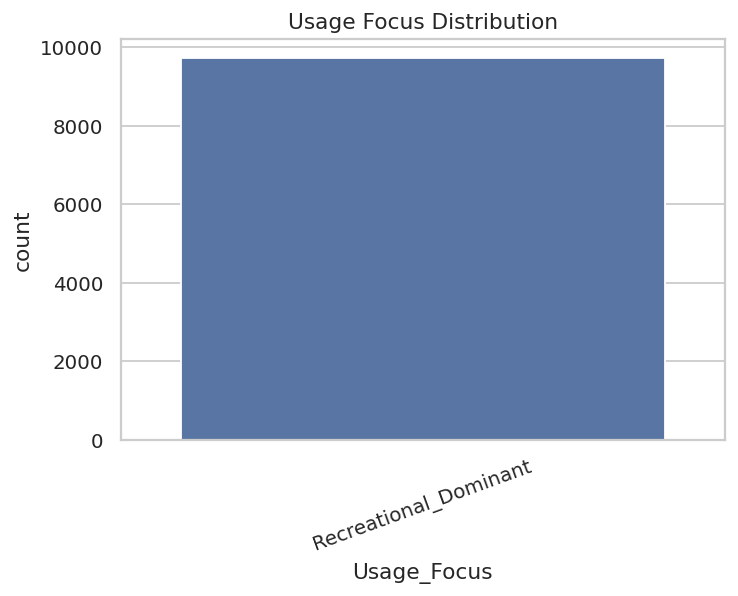

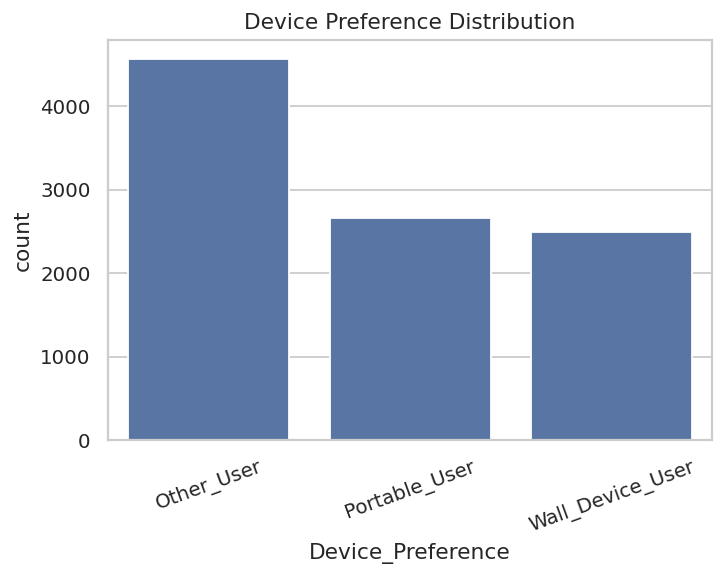

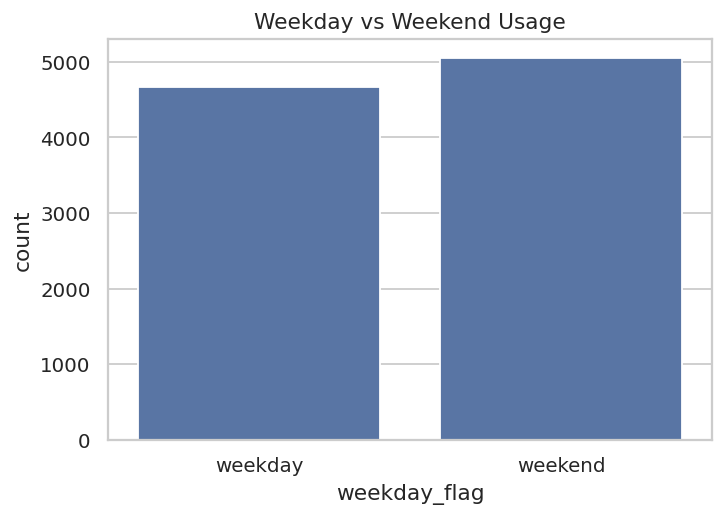

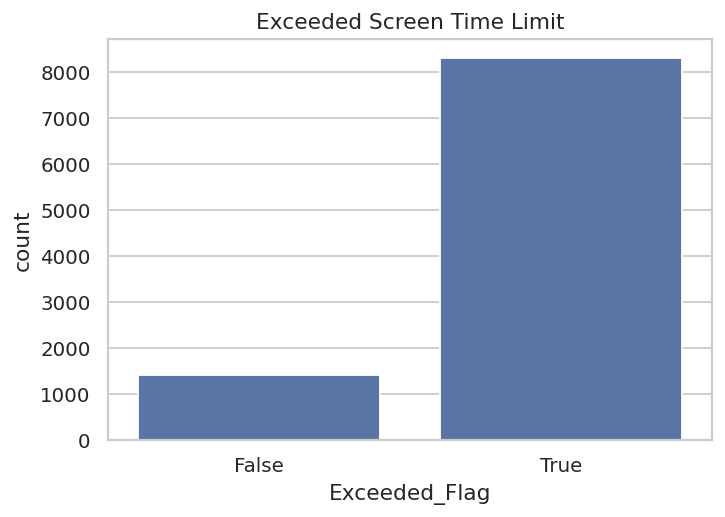

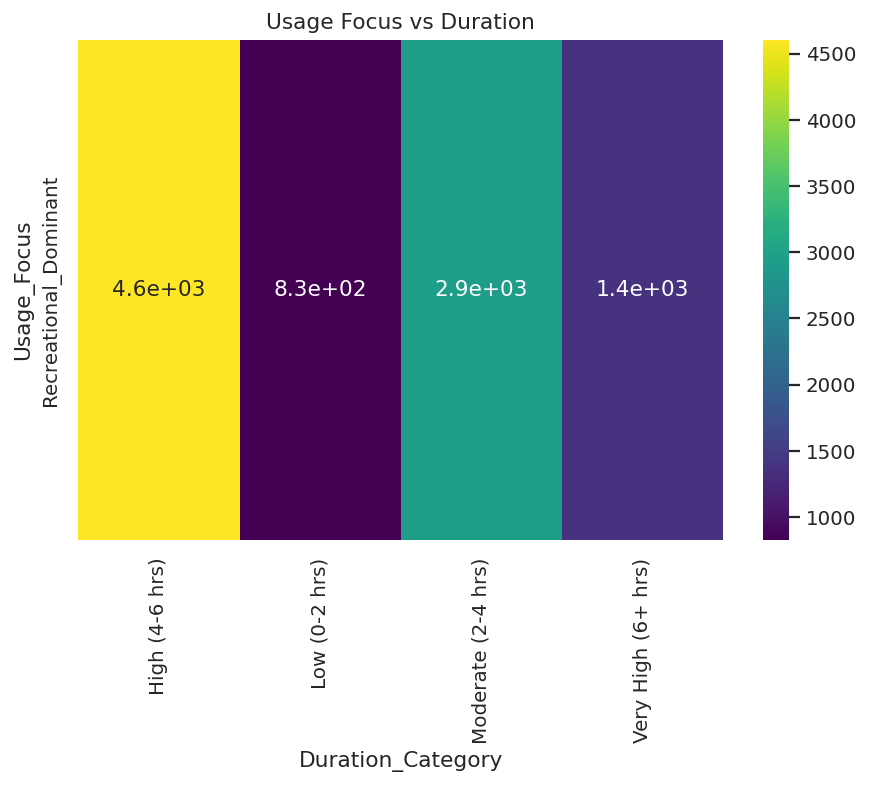

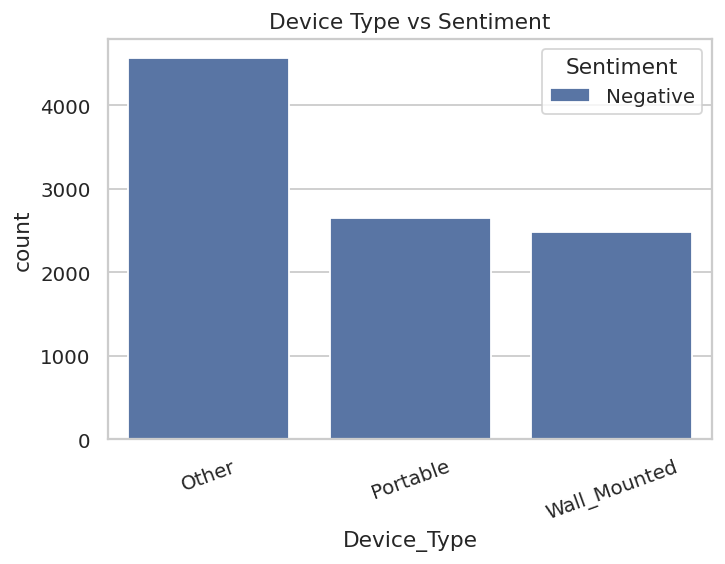

 FINAL KEY INSIGHTS
1. Portable devices are the most commonly used among all users.
2. High screen time duration (4–6 hrs and above) is significantly frequent.
3. Recreational usage dominates over educational usage.
4. Most users fall under the Recreational_Dominant category.
5. Negative health impacts are highly prevalent across users.
6. Poor sleep appears as the most common issue among users.
7. Users exceeding screen time limits form a major portion of the dataset.
8. Weekend usage is slightly higher compared to weekdays.
9. Very high duration users are mostly associated with negative health impacts.
10. Device preference aligns strongly with actual device usage patterns.
11. Educational usage is comparatively low across all duration categories.
12. Users with high screen time are more likely to exceed recommended limits.
13. Health issues increase as duration category increases.
14. Recreational usage strongly correlates with higher screen time durations.
15. Cohort analysis revea

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_kids_screentime.csv")

sns.set_theme(style="whitegrid")

# -------------------------------
# 1. DEVICE TYPE DISTRIBUTION
# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(
    x='device_type',
    data=df,
    hue='Device_Type',
    palette='Blues',
    legend=False
)
plt.title('Device Type Usage Distribution')
plt.xticks(rotation=20)
plt.show()


# -------------------------------
# 2. COHORT ANALYSIS (Duration × Device)
# -------------------------------
cohort = df.groupby(['Duration_Category','Device_Type']).size().unstack()

plt.figure(figsize=(8,5))
sns.heatmap(cohort, annot=True, cmap='coolwarm', fmt=".0f")
plt.title('Cohort Analysis: Duration vs Device Type')
plt.show()


# -------------------------------
# 3. SENTIMENT ANALYSIS
# -------------------------------
# Clean Health Impact (list → string)
df['Health_Impact_Category'] = df['Health_Impact_Category'].astype(str)

def map_sentiment(x):
    if 'No Effect' in x:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Health_Impact_Category'].apply(map_sentiment)

plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df, color='steelblue')
plt.title('Sentiment Distribution')
plt.show()


# -------------------------------
# 4–10 PLOTS
# -------------------------------

# 4. Duration Category Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Duration_Category', data=df)
plt.title('Screen Time Duration Distribution')
plt.xticks(rotation=20)
plt.show()

# 5. Usage Focus Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Usage_Focus', data=df)
plt.title('Usage Focus Distribution')
plt.xticks(rotation=20)
plt.show()

# 6. Device Preference
plt.figure(figsize=(6,4))
sns.countplot(x='Device_Preference', data=df)
plt.title('Device Preference Distribution')
plt.xticks(rotation=20)
plt.show()

# 7. Weekday vs Weekend
plt.figure(figsize=(6,4))
sns.countplot(x='weekday_flag', data=df)
plt.title('Weekday vs Weekend Usage')
plt.show()

# 8. Exceeded Flag
plt.figure(figsize=(6,4))
sns.countplot(x='Exceeded_Flag', data=df)
plt.title('Exceeded Screen Time Limit')
plt.show()

# 9. Heatmap (Usage Focus × Duration)
pivot = df.pivot_table(index='Usage_Focus',
                       columns='Duration_Category',
                       aggfunc='size')

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap='viridis')
plt.title('Usage Focus vs Duration')
plt.show()

# 10. Device Type vs Sentiment
plt.figure(figsize=(6,4))
sns.countplot(x='Device_Type', hue='Sentiment', data=df)
plt.title('Device Type vs Sentiment')
plt.xticks(rotation=20)
plt.show()


# -------------------------------
# 15 INSIGHTS
# -------------------------------
print(" FINAL KEY INSIGHTS")
print("1. Portable devices are the most commonly used among all users.")
print("2. High screen time duration (4–6 hrs and above) is significantly frequent.")
print("3. Recreational usage dominates over educational usage.")
print("4. Most users fall under the Recreational_Dominant category.")
print("5. Negative health impacts are highly prevalent across users.")
print("6. Poor sleep appears as the most common issue among users.")
print("7. Users exceeding screen time limits form a major portion of the dataset.")
print("8. Weekend usage is slightly higher compared to weekdays.")
print("9. Very high duration users are mostly associated with negative health impacts.")
print("10. Device preference aligns strongly with actual device usage patterns.")
print("11. Educational usage is comparatively low across all duration categories.")
print("12. Users with high screen time are more likely to exceed recommended limits.")
print("13. Health issues increase as duration category increases.")
print("14. Recreational usage strongly correlates with higher screen time durations.")
print("15. Cohort analysis reveals that portable devices dominate across all duration levels.")